In [93]:
# ======================
# Basic Libraries 
# ======================
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

#======================
# Preprocessing
# =====================
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
#from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, RobustScaler, OneHotEncoder

#====================
# Model Selection
# =====================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ===================
# Evaluation Matrices
# =====================
from sklearn.metrics import classification_report, recall_score, precision_score, accuracy_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [94]:
path = os.path.join('..', 'data', 'titanic.csv')
df = pd.read_csv(path)

In [95]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [96]:
df.shape

(891, 12)

In [97]:
# Checking dataset null values columns 
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [98]:
# Feature engineering
df['Title'] = df['Name'].str.extract("([A-Za-z]+)\.", expand=False)
rare_title = ['Dr', 'Rev', 'Col', 'Major', 'Countess', 'Sir', 'Jonkheer', 'Lady', 'Capt', 'Don', 'Mme', 'Ms', 'Mlle']
df['Title'] = df['Title'].replace(rare_title, 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Family size and isalone
df['FamilySize'] = df['SibSp']+df['Parch']+1
df['IsAlone'] = np.where(df['FamilySize']==1, 1, 0)

# Extract Deck from Cabin and fill Nan with U
df['Cabin'] = df['Cabin'].fillna('U')
df['Deck'] = df['Cabin'].apply(lambda x: x[0])

# 

In [101]:
# the Cabin column has larg number of nan value so we will drop it eg 687/891, 
# Same 'Cabin', 'PassengerId', 'Ticket', 'Name' are useless because these have large numbers of unique values
df = df.drop(['Cabin', 'PassengerId', 'Ticket','Fare' ,'Name'], axis=1)

In [102]:
# We need to fill nan values of age column with median because it apropriate of it 
df['Age'] = df['Age'].fillna(df['Age'].median())

In [103]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Embarked      2
Title         0
FamilySize    0
IsAlone       0
Deck          0
dtype: int64

In [104]:
df.dropna(inplace=True)

In [105]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Embarked      0
Title         0
FamilySize    0
IsAlone       0
Deck          0
dtype: int64

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    int64  
 1   Pclass      889 non-null    int64  
 2   Sex         889 non-null    object 
 3   Age         889 non-null    float64
 4   SibSp       889 non-null    int64  
 5   Parch       889 non-null    int64  
 6   Embarked    889 non-null    object 
 7   Title       889 non-null    object 
 8   FamilySize  889 non-null    int64  
 9   IsAlone     889 non-null    int64  
 10  Deck        889 non-null    object 
dtypes: float64(1), int64(6), object(4)
memory usage: 83.3+ KB


In [107]:
df.nunique()

Survived       2
Pclass         3
Sex            2
Age           88
SibSp          7
Parch          7
Embarked       3
Title          5
FamilySize     9
IsAlone        2
Deck           9
dtype: int64

In [108]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,889.0,0.382452,0.486260,0.00,0.0,0.0,1.0,1.0
Pclass,889.0,2.311586,0.834700,1.00,2.0,3.0,3.0,3.0
Age,889.0,29.315152,12.984932,0.42,22.0,28.0,35.0,80.0
SibSp,889.0,0.524184,1.103705,0.00,0.0,0.0,1.0,8.0
Parch,889.0,0.382452,0.806761,0.00,0.0,0.0,0.0,6.0
FamilySize,889.0,1.906637,1.614703,1.00,1.0,1.0,2.0,11.0
IsAlone,889.0,0.601800,0.489803,0.00,0.0,1.0,1.0,1.0


C:\Users\murtaza\AppData\Local\Temp\ipykernel_7392\2822187208.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax=axis);


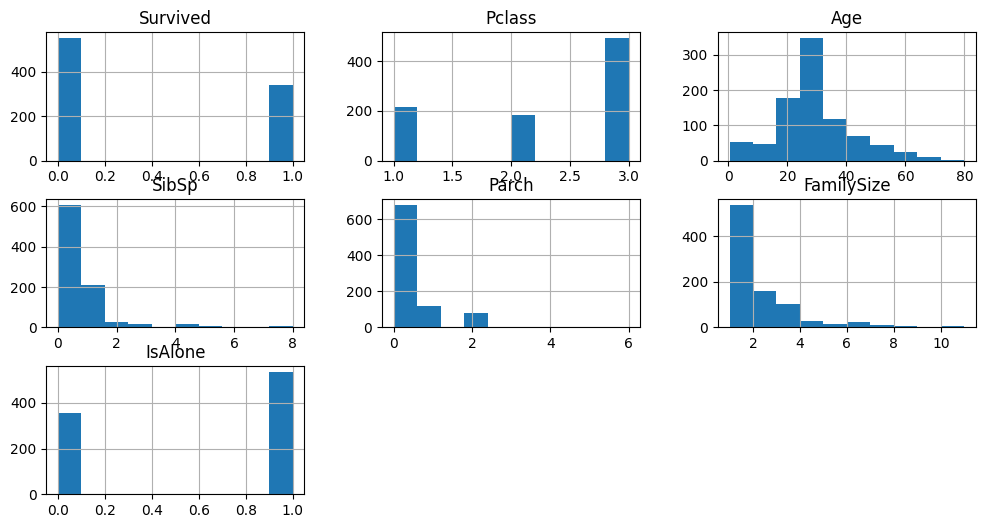

In [112]:
fig, axis = plt.subplots( figsize=(12,6))
df.hist(ax=axis);

<Axes: xlabel='Age', ylabel='FamilySize'>

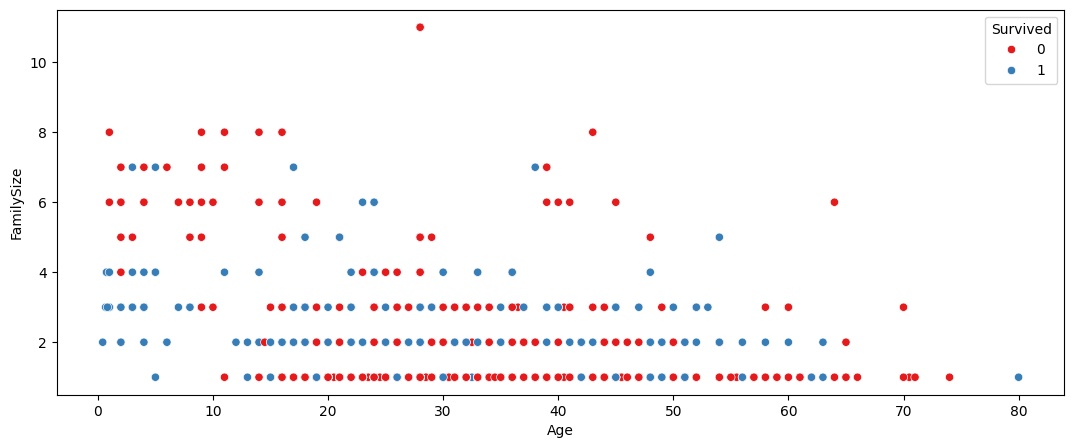

In [114]:
plt.figure(figsize=(13,5))
sns.scatterplot(data=df, x='Age', y='FamilySize', hue= 'Survived', palette='Set1')

In [115]:
count = df['Survived'].value_counts()
labels=['Died', 'Survived']
count

Survived
0    549
1    340
Name: count, dtype: int64

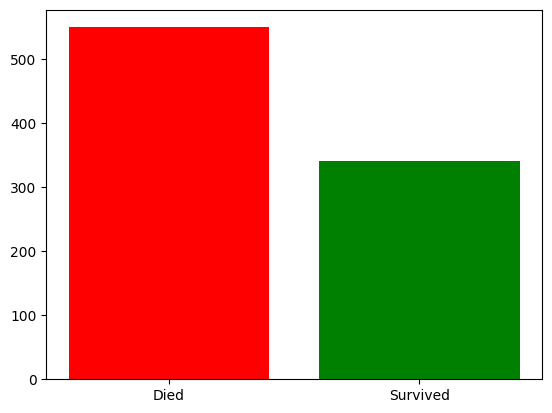

In [116]:
plt.figure()
plt.bar(labels, count, color=['Red', 'green']);


In [126]:
df.corr(numeric_only=True)

,Survived,Pclass,Age,SibSp,Parch,FamilySize,IsAlone
Survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.018277,-0.206207
Pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,0.064221,0.138553
Age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,-0.244631,0.169518
SibSp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.890654,-0.584186
Parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.782988,-0.583112
FamilySize,0.018277,0.064221,-0.244631,0.890654,0.782988,1.000000,-0.690654
IsAlone,-0.206207,0.138553,0.169518,-0.584186,-0.583112,-0.690654,1.000000


In [118]:
# Dividing into X and y features
X = df.drop('Survived', axis=1)
y = df['Survived']

In [119]:
# Splitting into train test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [157]:
# Preprocessing the data eg encoding the catogrical data
log_transformer = FunctionTransformer(np.log1p, validate=True, feature_names_out='one-to-one')
preprocessor = ColumnTransformer(
    transformers=[
    ('encoder', OneHotEncoder(), ['Sex', 'Embarked', 'Pclass', 'Title', 'Deck', 'IsAlone']),
    ('log_trans', log_transformer, ['Age', 'FamilySize']),
    ('robust_scaler', RobustScaler(), ['SibSp'])
],
remainder = 'passthrough')
pipe_l = Pipeline(steps=[
    ('preprcessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced'))
])

In [158]:
pipe_l_f = pipe_l.fit(X_train, y_train)

In [159]:
y_pred = pipe_l.predict(X_test)

In [160]:
accuracy_score(y_test, y_pred)

0.8258426966292135

In [161]:
precision_score(y_test, y_pred)

0.7402597402597403

In [150]:
recall_score(y_test, y_pred)

0.8382352941176471

In [134]:
pipe_r = Pipeline(steps=[
    ('preprcessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced'))
])

In [30]:
pipe_r.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprcessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoder', ...), ('scaller', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [31]:
y_pred = pipe_r.predict(X_test)
accuracy_score(y_test, y_pred)

0.8146067415730337

In [32]:
(precision_score(y_test, y_pred))*100

76.92307692307693

In [33]:
(recall_score(y_test, y_pred))*100

73.52941176470588

In [34]:
df.corr(numeric_only=True)['Survived'].sort_values(ascending=False)

Survived    1.000000
Fare        0.255290
Parch       0.083151
SibSp      -0.034040
Age        -0.069822
Pclass     -0.335549
Name: Survived, dtype: float64

In [35]:
df.corr(numeric_only=True)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
Pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
Age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
SibSp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
Parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
Fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


In [127]:
# We will choose the simpler logistic model for further tunning because it's better than randomforest
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}
grid_search = GridSearchCV(
    estimator= pipe_l,
    param_grid = param_grid,
    cv = 5,
    n_jobs = -1
)

In [128]:
grid_search.fit(X_train, y_train)

C:\Users\murtaza\miniconda3\envs\ml\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
C:\Users\murtaza\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\murtaza\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.001, 0.01, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [129]:
grid_search.best_params_

{'model__C': 0.001, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

In [130]:
best_model = grid_search.best_estimator_

In [131]:
y_pred_gr = best_model.predict(X_test)

In [132]:
# We see that there is no special upgrade after hyperparameter tunning
print(classification_report(y_test, y_pred_gr))

              precision    recall  f1-score   support

           0       0.62      1.00      0.76       110
           1       0.00      0.00      0.00        68

    accuracy                           0.62       178
   macro avg       0.31      0.50      0.38       178
weighted avg       0.38      0.62      0.47       178



C:\Users\murtaza\miniconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\murtaza\miniconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\murtaza\miniconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [42]:
precision_score(y_test, y_pred_gr)

0.7536231884057971

In [43]:
recall_score(y_test, y_pred_gr)

0.7647058823529411

In [44]:
matric = confusion_matrix(y_test, y_pred_gr)

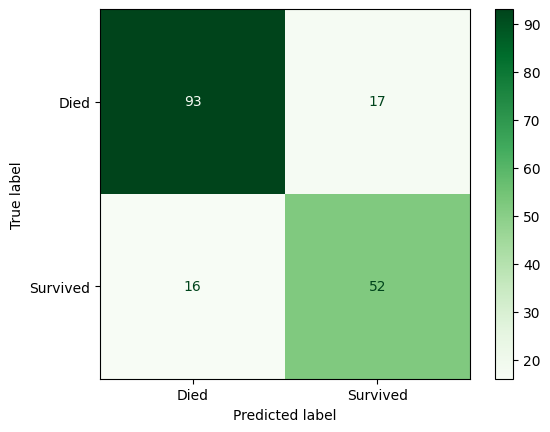

In [45]:
# we will draw confusion for visualizing where the model making mistake more
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gr,
    display_labels = ['Died', 'Survived'],
    cmap = plt.cm.Greens
)

In [46]:
#Tunning RandomForest 
param_distributions = {
    'model__n_estimators': [100, 200, 400],
    'model__max_depth' : [None, 3, 5, 10],
    'model__min_samples_split' : [2, 5, 10],
    'model__min_samples_leaf' : [1, 2, 4], 
    'model__max_features' : ['sqrt', 'log2', 0.5]
}

random_search = RandomizedSearchCV(
    estimator = pipe_r,
    param_distributions = param_distributions,
    n_iter = 15,
    cv = 5,
    scoring= 'f1',
    random_state = 42,
    n_jobs = -1
)

In [47]:
y_predss = best_r.predict(X_test)

NameError: name 'best_r' is not defined

In [50]:
best_r = random_search.best_estimator_

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_estimator_'

In [ ]:
accuracy_score(y_test, y_predss)

In [ ]:
print(classification_report(y_test, y_predss))

In [135]:
pipe_x = Pipeline(steps=[
    ('preprcessor', preprocessor),
    ('model', XGBClassifier())
])

In [52]:
pipe_x.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprcessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoder', ...), ('scaller', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [53]:
y_predx = pipe_x.predict(X_test)
accuracy_score(y_test, y_predx)

0.8089887640449438

In [54]:
print(classification_report(y_test, y_predx))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84       110
           1       0.73      0.79      0.76        68

    accuracy                           0.81       178
   macro avg       0.80      0.81      0.80       178
weighted avg       0.81      0.81      0.81       178



In [136]:
from sklearn.ensemble import VotingClassifier

# Use the best tuned versions of your three models
voting_clf = VotingClassifier(
    estimators=[
        ('lr', pipe_r),
        ('rf', pipe_l),   # Your tuned Random Forest
        ('xgb', pipe_x)  # Your tuned XGBoost
    ],
    voting='soft' # 'soft' uses prediction probabilities, usually more accurate
)

voting_clf.fit(X_train, y_train)
# Test this model—it frequently bumps accuracy by 1% to 3%


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoder', ...), ('log_trans', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islowe

In [138]:
y_pred_v = voting_clf.predict(X_test)
print(classification_report(y_test, y_pred_v))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       110
           1       0.72      0.74      0.73        68

    accuracy                           0.79       178
   macro avg       0.78      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178



In [162]:
coeficient = pipe_l_f.named_steps['model'].coef_
features = pipe_l_f.named_steps['preprcessor'].get_feature_names_out()

In [168]:
data = pd.DataFrame({
    'features' : features,
    'coefficient': coeficient.flatten()
})

In [171]:
data.sort_values(by='coefficient',ascending=False)

,features,coefficient
8,encoder__Title_Master,1.435358
0,encoder__Sex_female,0.926572
17,encoder__Deck_E,0.676865
16,encoder__Deck_D,0.580556
5,encoder__Pclass_1,0.566648
14,encoder__Deck_B,0.281057
11,encoder__Title_Mrs,0.272706
15,encoder__Deck_C,0.231685
3,encoder__Embarked_Q,0.195676
25,log_trans__FamilySize,0.191219


In [172]:
joblib.dump(pipe_l_f, 'logistic_model.pkl')

['logistic_model.pkl']